In [34]:
import pandas as pd
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
import numpy as np
from rdkit.Chem import Descriptors
import glob
from mordred import Calculator, descriptors

## Data collection

In [2]:
target_api = new_client.target
activity_api = new_client.activity

target_id = "CHEMBL287"
activities = activity_api.filter(target_chembl_id=target_id).filter(standard_type="Ki")

In [3]:
df = pd.DataFrame.from_dict(activities)

In [4]:
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,NaN,32922,[],CHEMBL802065,Compound was tested for its binding affinity t...,B,None,None,BAO_0000192,...,Homo sapiens,Sigma non-opioid intracellular receptor 1,9606,NaN,None,Ki,nM,UO_0000065,NaN,20.0
1,None,NaN,34604,[],CHEMBL804962,Binding affinity against the sigma receptor fr...,B,None,None,BAO_0000192,...,Homo sapiens,Sigma non-opioid intracellular receptor 1,9606,NaN,None,Ki,nM l-1,UO_0000065,NaN,270.0
2,None,NaN,39415,[],CHEMBL804963,Binding affinity against the sigma receptor of...,B,None,None,BAO_0000192,...,Homo sapiens,Sigma non-opioid intracellular receptor 1,9606,NaN,None,Ki,nM l-1,UO_0000065,NaN,34.0
3,None,NaN,39416,[],CHEMBL804962,Binding affinity against the sigma receptor fr...,B,None,None,BAO_0000192,...,Homo sapiens,Sigma non-opioid intracellular receptor 1,9606,NaN,None,Ki,nM l-1,UO_0000065,NaN,19.0
4,None,NaN,39946,[],CHEMBL810658,Ability to displace [3H](+)-pentazocine from S...,B,None,None,BAO_0000192,...,Homo sapiens,Sigma non-opioid intracellular receptor 1,9606,NaN,None,Ki,nM,UO_0000065,NaN,170.0


In [5]:
df.shape

(4540, 46)

In [6]:
df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='str')

In [7]:
df.to_csv("data_raw.csv", index=False)

## Cleaning

In [8]:
df_ki = df[df['standard_type'] == 'Ki'].copy()

In [9]:
df_clean = df_ki.dropna(subset=['standard_value', 'canonical_smiles']).copy()

In [10]:
df_clean.shape

(3705, 46)

In [11]:
df_clean['standard_value'] = df_clean['standard_value'].astype(float)

In [12]:
df_clean['pKi'] = -np.log10(df_clean['standard_value'] * 1e-9)

In [13]:
df_clean = df_clean[df_clean['standard_value'] > 0]

In [14]:
df_clean.shape

(3705, 47)

## Duplicates

In [15]:
df_clean = df_clean.sort_values(by='canonical_smiles')
df_prep = df_clean.groupby('canonical_smiles').agg({
    'pKi': 'median',
    'molecule_chembl_id': 'first',
    'document_journal': 'nunique'
}).reset_index()

In [16]:
df_prep = df_prep.rename(columns={'document_journal': 'source_count'})

In [17]:
df_prep.shape

(2940, 4)

## Classification Labeling

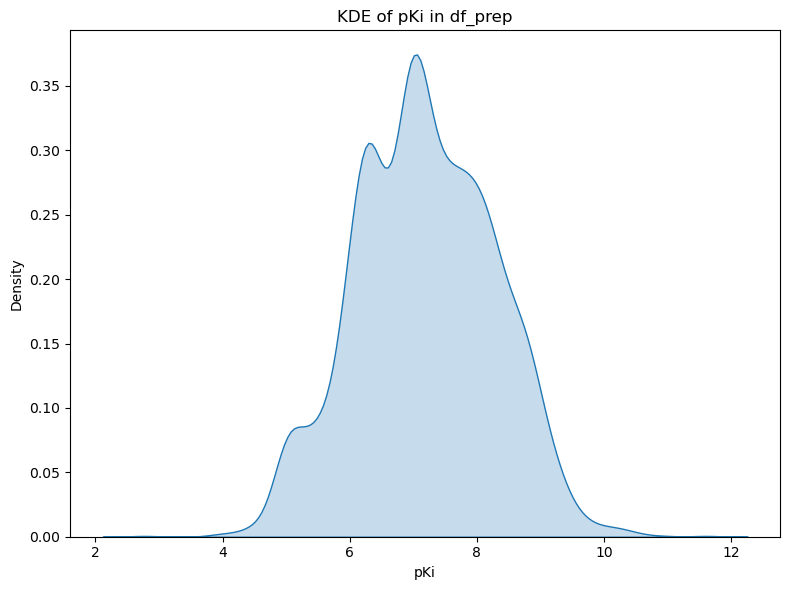

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.kdeplot(data=df_prep, x='pKi', fill=True)
plt.xlabel('pKi')
plt.title('KDE of pKi in df_prep')
plt.tight_layout()
plt.show()

In [19]:
df_labelled = df_prep.copy()

In [ ]:
# define active as pKi >= 7
# define inactive as pKi < 6.5
def classify_activity(pki):
    if pki >= 7:
        return 1
    elif pki <= 6.5:
        return 0
    else:
        return np.nan

df_labelled['active'] = df_labelled['pKi'].apply(classify_activity)

In [21]:
df_labelled.groupby('active')['active'].count()

active
0.0     846
1.0    1720
Name: active, dtype: int64

In [22]:
df_labelled.isna().sum()

canonical_smiles        0
pKi                     0
molecule_chembl_id      0
source_count            0
active                374
dtype: int64

In [23]:
df_final = df_labelled.dropna(subset=['active']).copy()
df_final['active'] = df_final['active'].astype(int)
cols_to_keep = ['molecule_chembl_id', 'canonical_smiles', 'pKi', 'active', 'source_count']
df_final = df_final[cols_to_keep]

print(df_final['active'].value_counts())


active
1    1720
0     846
Name: count, dtype: int64


## ZINC dataset

In [24]:
zinc_files = glob.glob('ZINC/*.smi')
df_list = []

In [25]:
for file in zinc_files:
    df_temp = pd.read_csv(file, sep='\\s+', names=['smiles', 'zinc_id'], header=0)
    df_list.append(df_temp)

In [26]:
df_zinc_all = pd.concat(df_list, ignore_index=True)
df_zinc_all = df_zinc_all.dropna(subset=['smiles'])

In [27]:
df_zinc_all.head()

,smiles,zinc_id
0,COc1cccc(/C=C2\Oc3cc(OC(=O)/C=C/c4ccccc4)ccc3C...,12662288
1,CCOc1cc(C#N)ccc1O[C@@H](C(=O)Nc1ccc(F)cc1)c1cc...,7509170
2,C#CCSc1nc2c(c(=O)n1CC=C)C1(CCCCC1)Cc1ccccc1-2,2081366
3,O=[N+]([O-])c1ccc([C@@H]2CCCC/C2=N\OCc2cccc(F)...,4014484
4,N#Cc1c2nc3ccccc3nc2n2cc(NC(=O)c3ccc(Cl)cc3)ccc12,5024618


In [28]:
df_zinc_all.shape

(6462001, 2)

### Use only a random sample from ZINC to speed everything up

In [48]:
df_zinc = df_zinc_all.sample(n=20000, random_state=42)

## Calculate descriptors

In [49]:
df_final['mol'] = df_final['canonical_smiles'].apply(Chem.MolFromSmiles)
df_zinc['mol'] = df_zinc['smiles'].apply(Chem.MolFromSmiles)

In [43]:
def calc_descriptors(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    return mw, logp, hbd, hba

In [50]:
df_final[['MW', 'LogP', 'HBD', 'HBA']] = df_final['mol'].apply(lambda m: pd.Series(calc_descriptors(m)))
df_zinc[['MW', 'LogP', 'HBD', 'HBA']] = df_zinc['mol'].apply(lambda m: pd.Series(calc_descriptors(m)))

In [45]:
calc = Calculator(descriptors, ignore_3D=True)

In [51]:
df_final_mordred = calc.pandas(df_final['mol'])
df_zinc_mordred = calc.pandas(df_zinc['mol'])

100%|██████████| 20000/20000 [16:40<00:00, 19.99it/s]


In [52]:
df_final_mordred = df_final_mordred.apply(pd.to_numeric, errors='coerce')
df_zinc_mordred = df_zinc_mordred.apply(pd.to_numeric, errors='coerce')

In [53]:
missing_fraction = df_final_mordred.isna().mean()
valid_missing_cols = missing_fraction[missing_fraction <= 0.10].index
final_cols = [col for col in valid_missing_cols if df_final_mordred[col].nunique(dropna=True) > 1]

df_final_mordred = df_final_mordred[final_cols]
df_zinc_mordred = df_zinc_mordred[final_cols]

In [55]:
df_final = pd.concat([df_final.reset_index(drop=True), df_final_mordred.reset_index(drop=True)], axis=1)
df_zinc = pd.concat([df_zinc.reset_index(drop=True), df_zinc_mordred.reset_index(drop=True)], axis=1)

## Saving the datasets

In [57]:
df_final.to_csv('data/data.csv', index=False)
df_zinc.to_csv('data/data_zinc.csv', index=False)

## Standardization

In [9]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from chembl_structure_pipeline import standardizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [10]:
df_receptor = pd.read_csv('data/data.csv', usecols=['molecule_chembl_id', 'canonical_smiles', 'pKi', 'active'])
df_zinc = pd.read_csv('data/data_zinc.csv', usecols=['smiles', 'zinc_id'])

In [11]:
def standardize_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    
    try:
        std_mol = standardizer.standardize_mol(mol)
        
        parent_mol, _ = standardizer.get_parent_mol(std_mol)
        std_smiles = Chem.MolToSmiles(parent_mol)
        
        return parent_mol, std_smiles
    except:
        return None, None

In [12]:
df_receptor[['std_mol', 'std_smiles']] = df_receptor['canonical_smiles'].apply(
    lambda x: pd.Series(standardize_molecule(x))
)

[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Uncharger
[22:45:33] Running Normalizer
[22:45:33] Running Uncharger
[22:4

In [13]:
df_zinc[['std_mol', 'std_smiles']] = df_zinc['smiles'].apply(
    lambda x: pd.Series(standardize_molecule(x))
)

[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Uncharger
[22:45:38] Running Normalizer
[22:45:38] Running Uncharger
[22:4

In [14]:
df_zinc.isna().sum()

smiles        0
zinc_id       0
std_mol       0
std_smiles    0
dtype: int64

In [15]:
df_receptor.isna().sum()

molecule_chembl_id    0
canonical_smiles      0
pKi                   0
active                0
std_mol               0
std_smiles            0
dtype: int64

In [16]:
df_receptor.drop(columns=['std_mol']).to_csv('data/receptor_std.csv', index=False)
df_zinc.drop(columns=['std_mol']).to_csv('data/zinc_std.csv', index=False)